# Разведывательный анализ данных (EDA) успеваемости студентов

**Датасет:** Students Academic Performance (Kaggle)  
Ссылка: https://www.kaggle.com/datasets/sharmajicoder/students-academic-performance

В этом ноутбуке проводится подробный анализ большого синтетического датасета (1 млн строк, 50 признаков). Мы изучим структуру данных, проверим пропуски, посмотрим на распределение целевых переменных для задач регрессии и классификации, построим топы категорий, оценим корреляции и найдем выбросы.


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

## 1. Загрузка и общий осмотр данных
Загружаем файл датасета, смотрим на его размер, типы признаков и базовые статистики.

In [47]:
path = "/content/student_academic_performance_1M.csv"
df = pd.read_csv(path)

print("Размер датасета:", df.shape)
display(df.head())

Размер датасета: (1000000, 52)


,math_score,science_score,english_score,history_score,computer_score,attendance_rate,assignment_avg,quiz_avg,project_score,previous_gpa,study_hours_daily,revision_hours,age,gender,urban_flag,family_size,parent_education,family_income,sleep_hours,physical_activity,screen_time,junk_food_freq,bmi,illness_days,mental_stress,sleep_quality,internet_access,private_tuition,tuition_hours,study_room,parent_involvement,scholarship_flag,part_time_job_hours,financial_stress,online_course_hours,lms_login_frequency,coding_practice_hours,ai_tool_usage,digital_literacy,video_watch_hours,forum_participation,device_availability,final_gpa,standardized_exam_score,improvement_next_term,dropout_risk_score,learning_efficiency,stress_index,pass_fail,honors_flag,at_risk_flag,top_performer_flag
0,62.456370,88.073740,72.526180,76.06144,92.64728,1.000000,104.827740,68.451580,81.24903,2.890757,5.424961,3.732179,21.0,1.0,1.0,5.0,4.0,0.086597,3.123178,20.320461,1.346347,5.101334,16.677050,9.799644,2.868216,4.627894,1.0,0.0,8.938710,1.0,8.587495,0.0,8.0,2.992787,3.596220,29.177130,4.594404,1.0,4.489380,7.591142,4.0,2.0,4.000000,78.581310,2.040133,0.001787,-1.235061,5.918975,1,0,0,0
1,56.778812,65.597540,69.882500,69.57163,71.62665,0.729115,51.119255,80.345620,81.51603,2.693535,2.389579,1.059061,23.0,1.0,1.0,7.0,3.0,0.258083,6.684560,28.900457,4.146213,3.061509,24.358055,7.904355,5.165138,9.883796,1.0,0.0,5.160551,1.0,4.233569,1.0,6.0,6.481065,0.526479,16.259508,2.080975,0.0,4.640371,3.860313,4.0,3.0,2.910472,52.727460,-1.696975,0.679032,1.416623,6.216345,1,0,1,0
2,78.238100,69.305824,76.588830,75.70467,67.68652,0.634656,47.222202,72.382280,58.76614,2.721305,0.295716,0.886814,19.0,0.0,1.0,3.0,0.0,0.207348,5.418255,22.330494,7.354021,2.908068,22.556710,7.241525,6.426495,6.009908,1.0,1.0,0.191834,1.0,2.301357,0.0,2.0,5.815330,6.159518,5.341212,2.169897,0.0,6.141655,7.715934,4.0,3.0,2.412240,73.162010,-1.354060,0.756908,0.684399,5.116631,1,0,1,0
3,86.619550,81.867950,87.423485,76.50009,86.60630,0.811508,69.160630,63.451378,49.04596,3.366405,3.244214,2.288499,17.0,2.0,1.0,5.0,1.0,0.263734,6.378703,72.264430,4.440588,5.327962,19.262655,7.566527,5.707565,3.780762,1.0,0.0,2.905022,0.0,4.893090,1.0,8.0,7.026944,3.468746,16.575195,2.622499,1.0,6.488314,7.798943,7.0,1.0,3.244543,85.844340,1.749234,0.962086,-1.249343,3.829115,1,0,1,0
4,65.569824,76.941990,67.950760,67.18360,73.40711,0.786856,44.262510,64.553490,48.36373,2.618776,0.464162,1.049923,16.0,2.0,1.0,6.0,5.0,0.133769,7.929658,36.667240,4.080064,2.578252,23.802835,7.464861,5.431078,5.309864,0.0,0.0,6.157549,0.0,5.706644,0.0,6.0,5.463260,0.000000,12.681294,3.019766,1.0,4.328275,3.839889,3.0,2.0,2.294958,56.980495,-0.747696,0.698020,-1.555532,4.509945,1,0,1,0


In [48]:
df.info()

print("\nКоличество строк:", df.shape[0])
print("Количество колонок:", df.shape[1])
print("Количество дубликатов:", df.duplicated().sum())
print("Общее количество пропусков во всем датасете:", df.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 52 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   math_score               1000000 non-null  float64
 1   science_score            1000000 non-null  float64
 2   english_score            1000000 non-null  float64
 3   history_score            1000000 non-null  float64
 4   computer_score           1000000 non-null  float64
 5   attendance_rate          1000000 non-null  float64
 6   assignment_avg           1000000 non-null  float64
 7   quiz_avg                 1000000 non-null  float64
 8   project_score            1000000 non-null  float64
 9   previous_gpa             1000000 non-null  float64
 10  study_hours_daily        1000000 non-null  float64
 11  revision_hours           1000000 non-null  float64
 12  age                      1000000 non-null  float64
 13  gender                   1000000 non-null  

In [49]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
math_score,1000000.0,64.990677,14.407658,-12.256755,55.282638,64.994800,74.703280,133.154240
science_score,1000000.0,68.004199,13.592084,1.516067,58.848191,67.996100,77.167130,130.585130
english_score,1000000.0,69.995202,11.395360,12.479786,62.305380,69.984695,77.691767,126.147410
history_score,1000000.0,66.009075,12.038289,8.838778,57.894759,66.006192,74.109052,124.252830
computer_score,1000000.0,72.000415,11.656679,16.025420,64.138298,71.995255,79.826735,130.191250
attendance_rate,1000000.0,0.749588,0.110521,0.192511,0.674851,0.750146,0.825543,1.000000
assignment_avg,1000000.0,60.007929,18.029055,-24.579021,47.863726,60.027060,72.166997,146.636960
quiz_avg,1000000.0,61.967112,15.612250,-15.261252,51.443364,61.956228,72.499739,138.207050
project_score,1000000.0,64.991922,14.149333,-3.452648,55.436342,64.985785,74.519212,140.044400
previous_gpa,1000000.0,2.792335,0.622958,0.000000,2.368726,2.800029,3.230806,4.000000


**Вывод к блоку 1:**
Мы загрузили масштабный датасет (1 млн записей). Описательные статистики показывают диапазоны значений, а проверка на дубликаты и пропуски дает понять, насколько данные "чистые". Если пропусков нет, можно сразу переходить к анализу, если есть — потребуется их заполнение или удаление перед обучением моделей.

## 2. Описание датасета

В датасете каждая строка содержит 51 признак об одном студенте.

### Основные признаки:

- **Успеваемость:** math_score, science_score, attendance_rate, и т.д.
- **Демография:** age, gender (encoded), parent_education и т.д.
- **Здоровье и образ жизни:** sleep_hours, physical_activity, illness_days и т.д.
- **Социально-экономические факторы и поддержка:** internet_access, parent_involvement, part_time_job_hours и т.д.
- **Цифровое обучение и поведение:** online_course_hours, digital_literacy, video_watch_hours и т.д.

## 3. Анализ целевых переменных (Регрессия и Классификация)
Определим две целевые переменные: одну числовую `final_gpa` для задачи регрессии и одну категориальную `pass_fail` для классификации.

Целевая переменная для регрессии: final_gpa
Целевая переменная для классификации: pass_fail


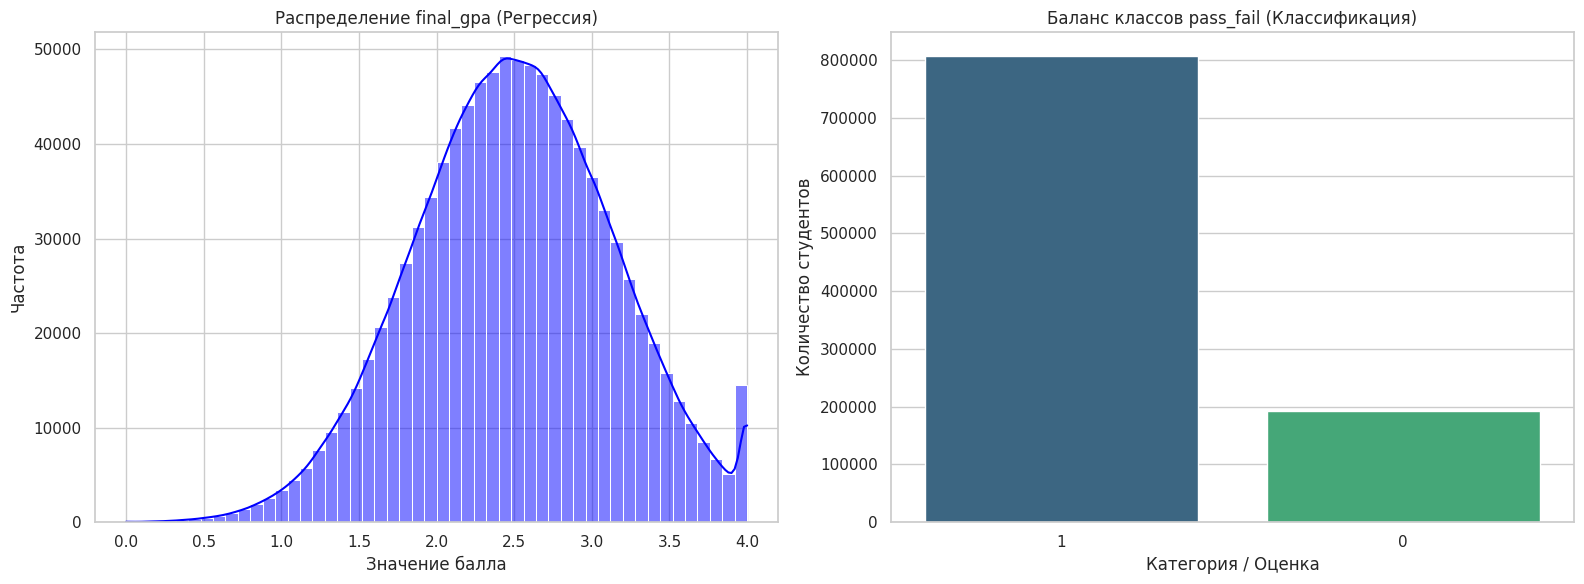

In [50]:
target_reg = "final_gpa" # Целевая переменная для регрессии
target_clf = "pass_fail"       # Целевая переменная для классификации

# Автоматический подбор, если колонки не найдены (для универсальности кода)
if target_reg not in df.columns:
    target_reg = df.select_dtypes(include=np.number).columns[-1]
if target_clf not in df.columns:
    cat_cols = df.select_dtypes(exclude=np.number).columns
    target_clf = cat_cols[-1] if len(cat_cols) > 0 else df.columns[-2]

print(f"Целевая переменная для регрессии: {target_reg}")
print(f"Целевая переменная для классификации: {target_clf}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График для регрессии
sns.histplot(df[target_reg], bins=50, kde=True, color='blue', ax=axes[0])
axes[0].set_title(f'Распределение {target_reg} (Регрессия)')
axes[0].set_xlabel('Значение балла')
axes[0].set_ylabel('Частота')

# График для классификации
sns.countplot(x=df[target_clf], palette='viridis', ax=axes[1], order=df[target_clf].value_counts().index)
axes[1].set_title(f'Баланс классов {target_clf} (Классификация)')
axes[1].set_xlabel('Категория / Оценка')
axes[1].set_ylabel('Количество студентов')

plt.tight_layout()
plt.show()

**Вывод к блоку 3:**
Анализ распределения числовой переменной (`final_gpa`) показывает, насколько данные скошены и есть ли ярко выраженный средний балл у большинства студентов. График категориальной переменной (`pass_fail`) позволяет оценить баланс классов. Если одних оценок в разы больше, чем других, при обучении классификатора придется использовать методы балансировки (например, SMOTE или веса классов).

## 4. Корреляционный анализ
Строим матрицу корреляций для выявления линейной зависимости между признаками и целевой числовой переменной.

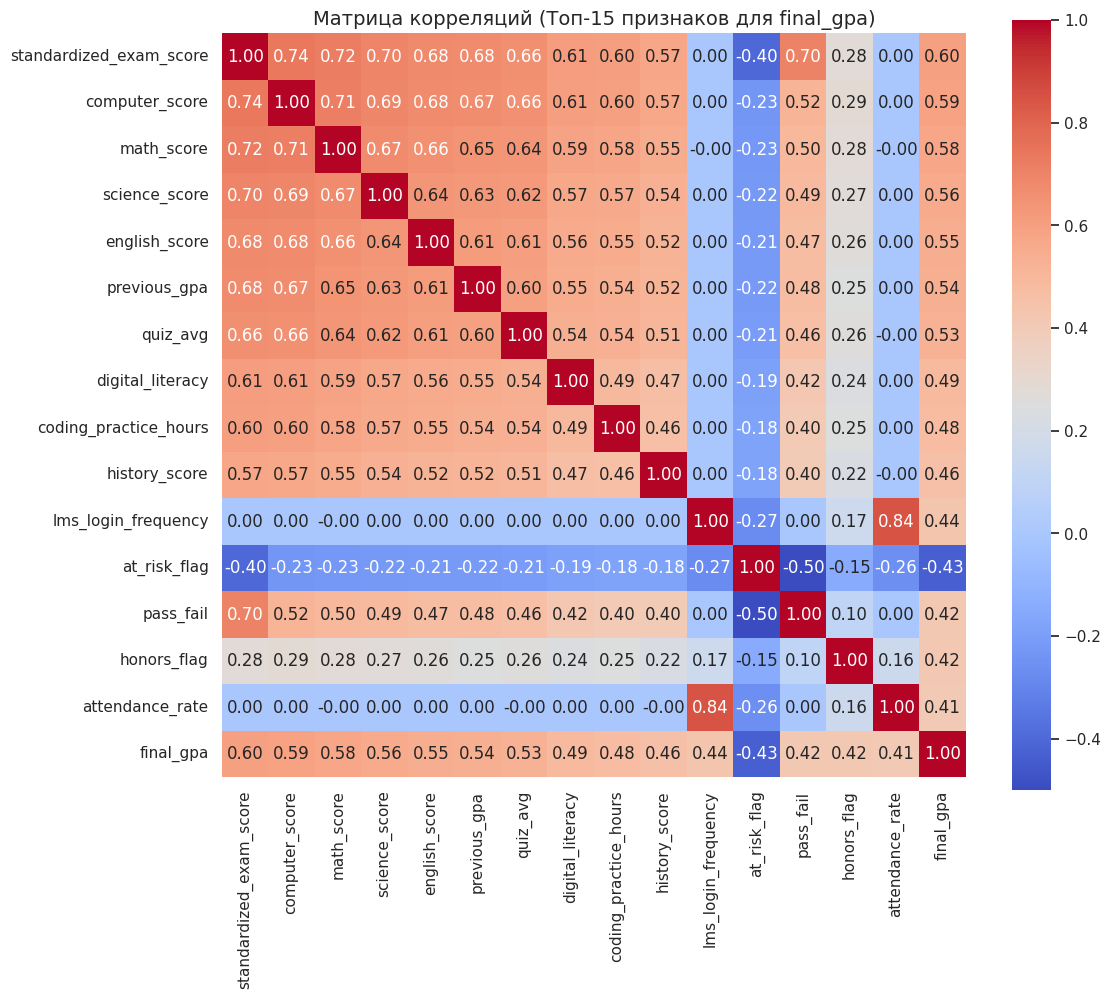

In [52]:
# Оставляем только числовые признаки для корреляции
numeric_df = df.select_dtypes(include=np.number)

correlations = numeric_df.corr()[target_reg].drop(target_reg)
top_features = correlations.abs().sort_values(ascending=False).head(15).index
top_corr = numeric_df[top_features.tolist() + [target_reg]].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(top_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title(f"Матрица корреляций (Топ-15 признаков для {target_reg})", fontsize=14)
plt.show()

**Вывод к блоку 3:**
Тепловая карта помогает выявить мультиколлинеарность (когда два признака сильно зависят друг от друга) и найти признаки, имеющие наибольшее влияние на таргет. Если признак имеет корреляцию, близкую к нулю, он, вероятно, будет слабо полезен для линейных моделей регрессии.

## 5. Распределение признаков и анализ выбросов
Сделаем срез данных на 100к строк для ускорения отрисовки графиков, затем построим гистограммы и boxplot для топ-6 самых скоррелированных признаков.

Строим распределения для следующих признаков: ['standardized_exam_score', 'computer_score', 'math_score', 'science_score', 'english_score', 'previous_gpa']


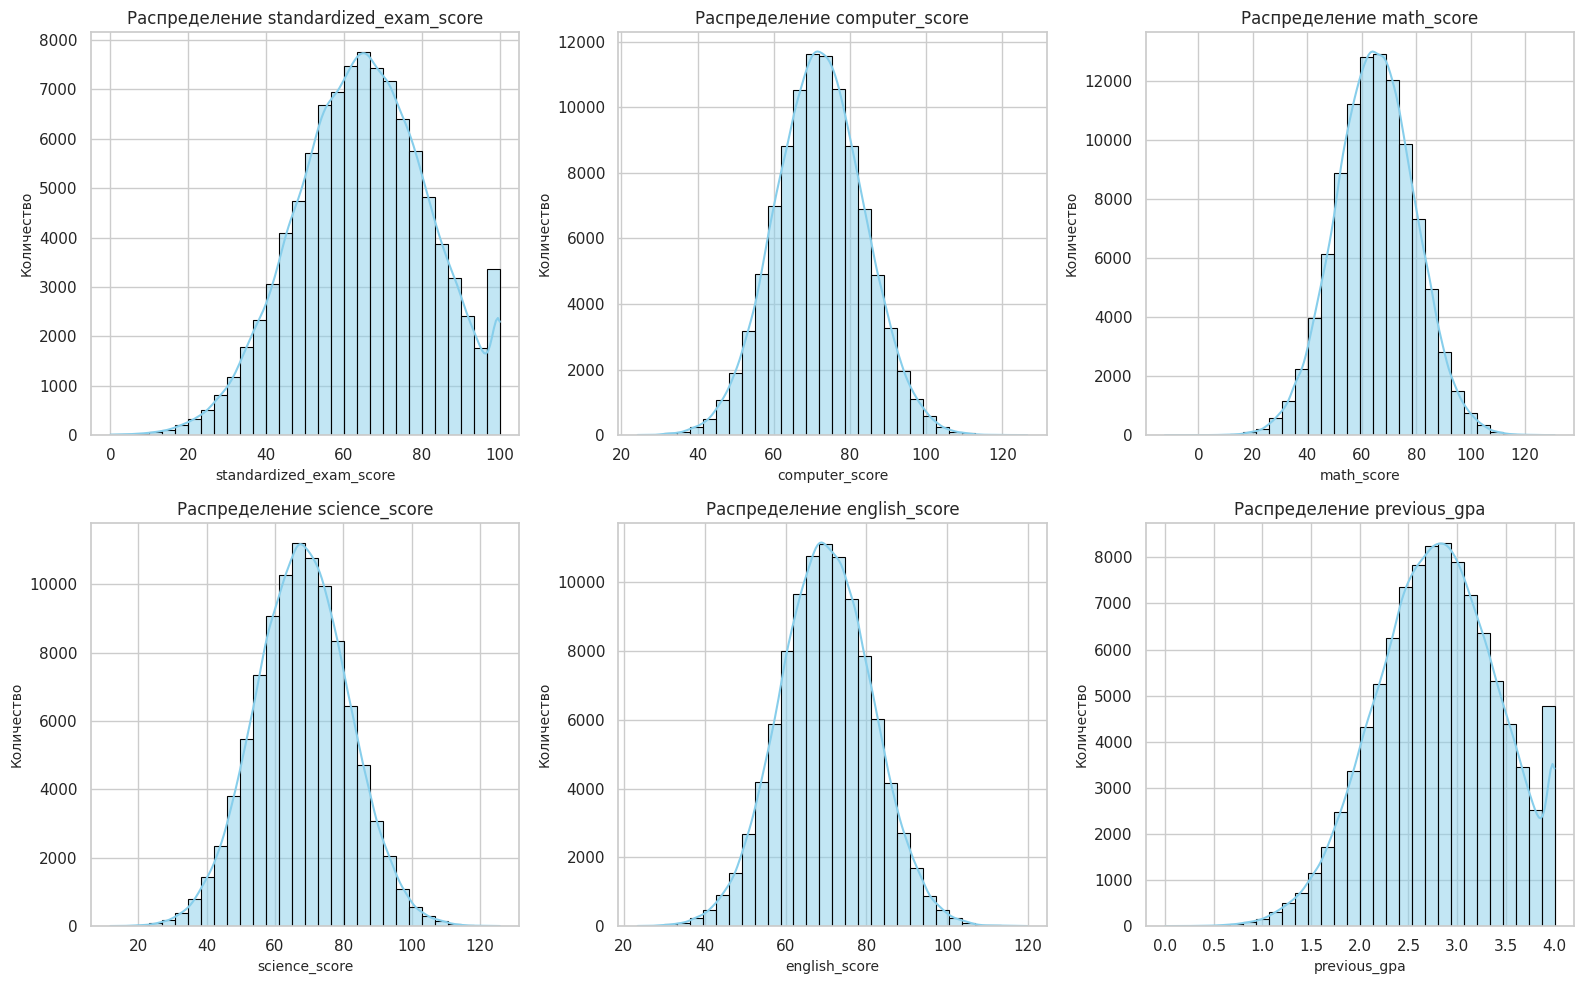

In [53]:
df_sample = df.sample(n=min(100000, len(df)), random_state=42)
features_to_plot = correlations.abs().sort_values(ascending=False).head(6).index.tolist()
print(f"Строим распределения для следующих признаков: {features_to_plot}")

plt.figure(figsize=(16, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_sample[col], bins=30, kde=True, color='skyblue', edgecolor='black')
    plt.title(f'Распределение {col}', fontsize=12)
    plt.ylabel('Количество', fontsize=10)
    plt.xlabel(col, fontsize=10)
plt.tight_layout()
plt.show()

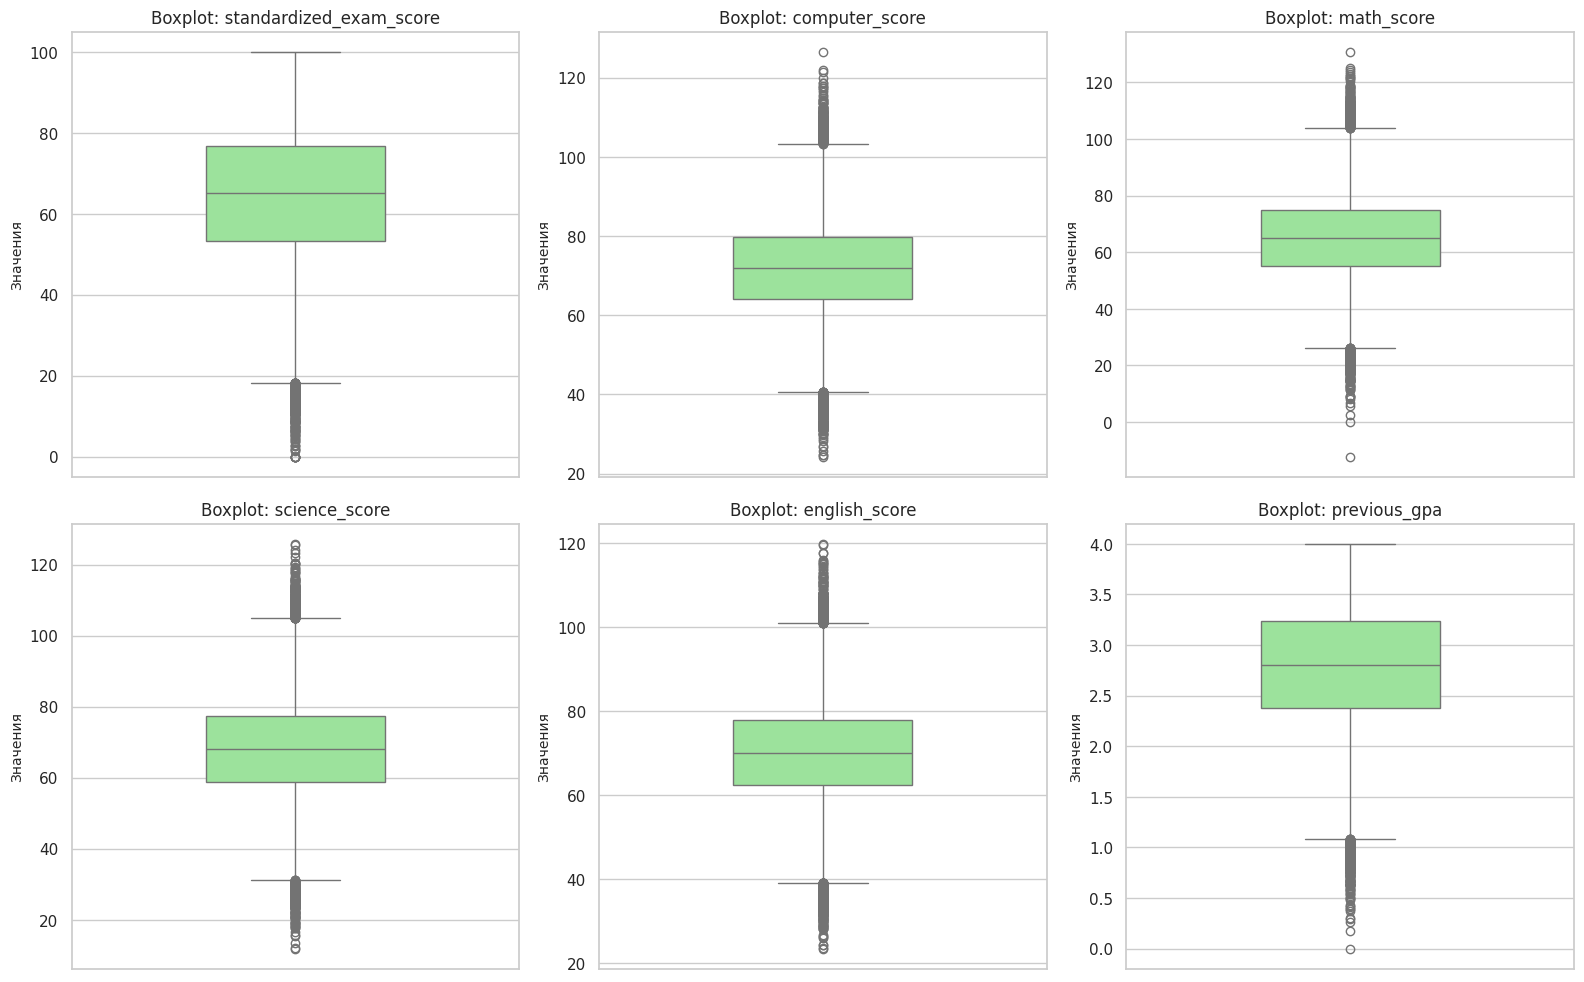

In [54]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_sample[col], color='lightgreen', width=0.4)
    plt.title(f'Boxplot: {col}', fontsize=12)
    plt.ylabel('Значения', fontsize=10)
plt.tight_layout()
plt.show()

**Вывод к блоку 5:**
Гистограммы позволяют увидеть характер распределения признаков (нормальное, бимодальное, со смещением). Boxplot-ы четко подсвечивают выбросы (точки за пределами "усов"). В зависимости от природы данных, выбросы можно удалить, обрезать (clipping) или оставить, если они представляют реальные аномальные явления в успеваемости студентов.

## 6. Влияет ли гендер на успеваемость?
В данном датасете признак `gender` имеет 3 значения(0 - мальчик, 1 - девочка, 2 - другой(но мы это не одобряем))

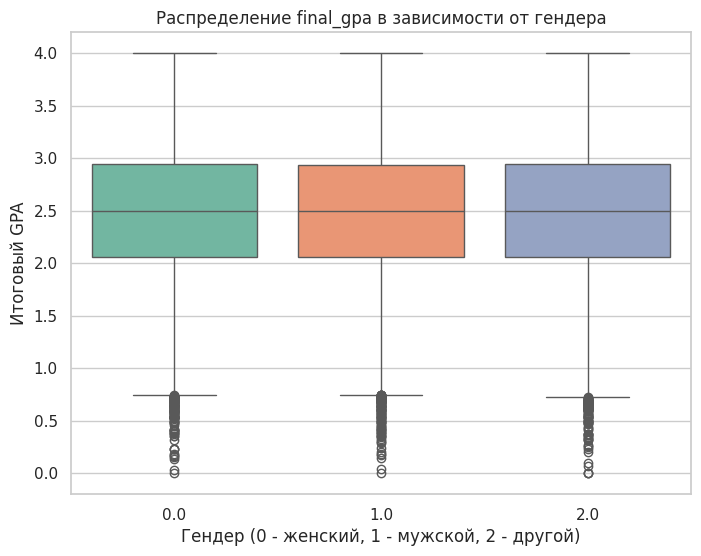

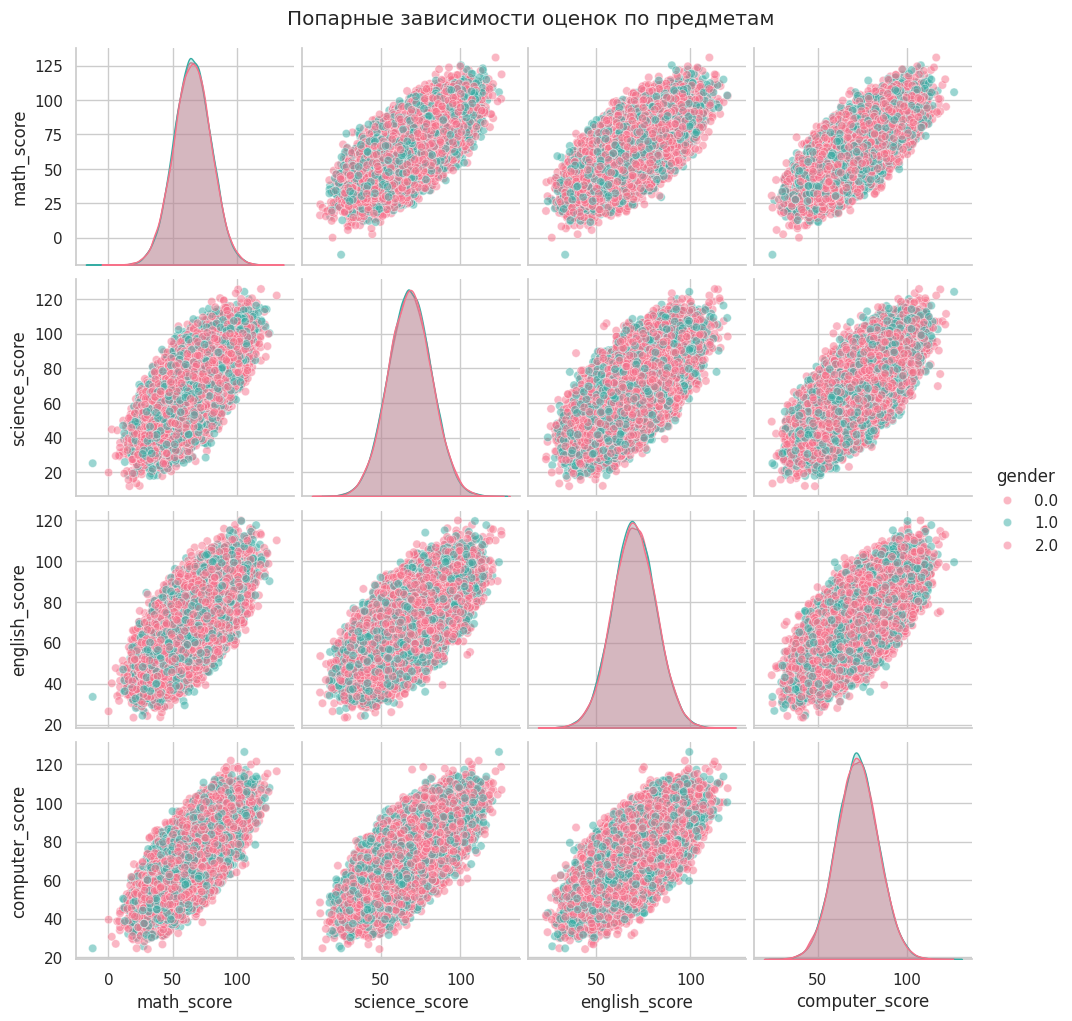

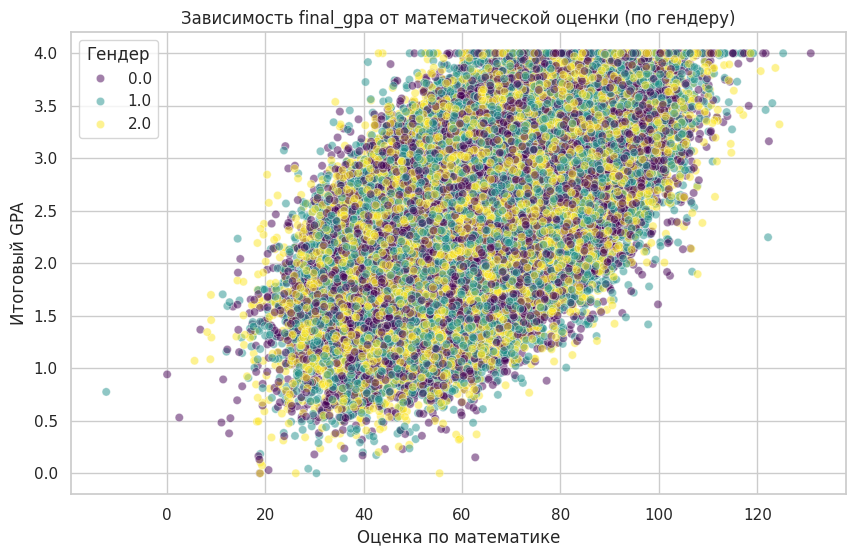

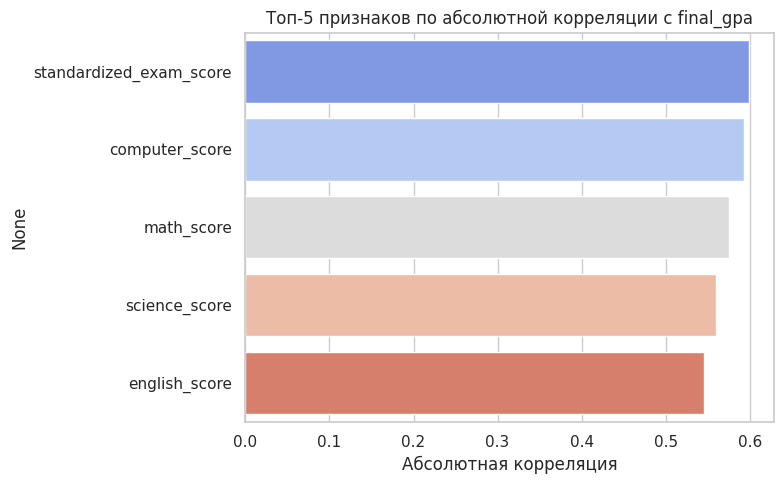

In [59]:
# Зависимость итогового GPA от гендера (сравнение боксплотов)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_sample, x='gender', y='final_gpa', palette='Set2')
plt.title('Распределение final_gpa в зависимости от гендера')
plt.xlabel('Гендер (0 - женский, 1 - мужской, 2 - другой)')
plt.ylabel('Итоговый GPA')
plt.show()

# Зависимость основный предметов с раскраской по гендеру
subjects = ['math_score', 'science_score', 'english_score', 'computer_score']
sns.pairplot(df_sample[subjects + ['gender']], hue='gender', diag_kind='kde',
             plot_kws={'alpha':0.5}, palette='husl')
plt.suptitle('Попарные зависимости оценок по предметам', y=1.02)
plt.show()

# Зависимость final_gpa от selected_score с учетом гендера(для построения конкретной зависимости)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='math_score', y='final_gpa', hue='gender', alpha=0.5, palette='viridis')
plt.title('Зависимость final_gpa от математической оценки (по гендеру)')
plt.xlabel('Оценка по математике')
plt.ylabel('Итоговый GPA')
plt.legend(title='Гендер')
plt.show()

# Топ 5 признаков по корреляции
top5_corr = correlations.abs().sort_values(ascending=False).head(5)
plt.figure(figsize=(8, 5))
sns.barplot(x=top5_corr.values, y=top5_corr.index, palette='coolwarm')
plt.title('Топ-5 признаков по абсолютной корреляции с final_gpa')
plt.xlabel('Абсолютная корреляция')
plt.tight_layout()
plt.show()

**Вывод к блоку 7:**
По графикам очевидно, что в данном датасете успеваемость не зависит от гендера, даже если он *другой*.

## 8. Сохранение выборки для обучения
Сохраняем случайную выборку (или весь очищенный датасет), чтобы в следующем ноутбуке сосредоточиться исключительно на машинном обучении.

In [55]:
df_sample.to_csv("student_performance_sample.csv", index=False)
print("Файл сохранён: student_performance_sample.csv (Размер:", df_sample.shape, ")")

Файл сохранён: student_performance_sample.csv (Размер: (100000, 52) )
